# K-Means Clustering with scikit-learn
Full sklearn pipeline: `KMeans` with K-Means++ init, elbow method, silhouette analysis.
Model saved to `../Models/kmeans_sklearn.joblib`.

## 1. Generate & Scale Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, os
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score
)
from sklearn.pipeline import Pipeline

X_raw, y_true = make_blobs(
    n_samples=1500, centers=4, n_features=2,
    cluster_std=0.9, random_state=42
)
print(f"Dataset: {X_raw.shape[0]:,} points  |  Features: {X_raw.shape[1]}  |  True clusters: 4")

Dataset: 1,500 points  |  Features: 2  |  True clusters: 4


## 2. Build sklearn Pipeline (Scaler + KMeans)

In [2]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(
        n_clusters  = 4,
        init        = 'k-means++',  # smart initialisation
        n_init      = 10,           # run 10 times, keep best inertia
        max_iter    = 300,
        tol         = 1e-4,
        random_state= 42
    ))
])

labels = pipeline.fit_predict(X_raw)
X_scaled = pipeline['scaler'].transform(X_raw)
km       = pipeline['kmeans']

print(f"Converged in {km.n_iter_} iterations  |  Inertia: {km.inertia_:.4f}")

Converged in 2 iterations  |  Inertia: 72.0156


## 3. Cluster Visualisation

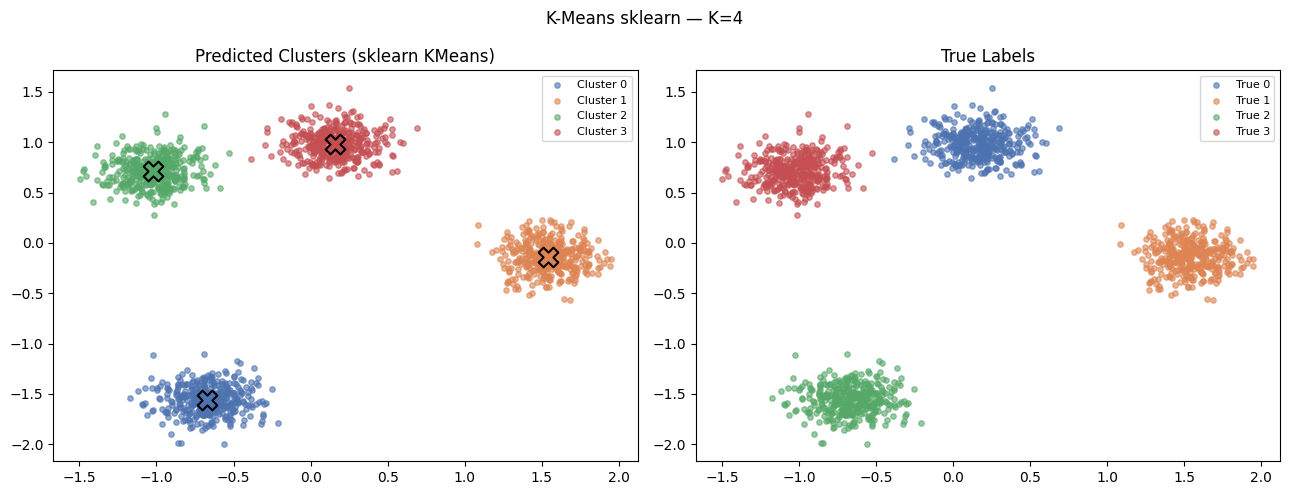

In [3]:
K      = 4
colors = ['#4C72B0','#DD8452','#55A868','#C44E52']
ctrs   = km.cluster_centers_      # in scaled space

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for j in range(K):
    pts = X_scaled[labels == j]
    ax1.scatter(pts[:, 0], pts[:, 1], s=15, alpha=0.6, color=colors[j], label=f'Cluster {j}')
    ax1.scatter(*ctrs[j], s=200, marker='X', color=colors[j], edgecolors='black', linewidths=1.5)
ax1.set_title('Predicted Clusters (sklearn KMeans)')
ax1.legend(fontsize=8)

for j in range(K):
    pts = X_scaled[y_true == j]
    ax2.scatter(pts[:, 0], pts[:, 1], s=15, alpha=0.6, color=colors[j], label=f'True {j}')
ax2.set_title('True Labels')
ax2.legend(fontsize=8)

plt.suptitle('K-Means sklearn — K=4', fontsize=12)
plt.tight_layout(); plt.show()

## 4. Evaluation Metrics

In [4]:
sil = silhouette_score(X_scaled, labels)
dbs = davies_bouldin_score(X_scaled, labels)
chs = calinski_harabasz_score(X_scaled, labels)
inn = km.inertia_

print(f"Inertia (WCSS)          : {inn:.4f}  (lower = tighter clusters)")
print(f"Silhouette Score        : {sil:.4f}  (higher = better, range -1..1)")
print(f"Davies-Bouldin Score    : {dbs:.4f}  (lower = better)")
print(f"Calinski-Harabasz Score : {chs:.4f}  (higher = better)")
print(f"Iterations to converge  : {km.n_iter_}  (best of {km.n_init} runs)")

Inertia (WCSS)          : 72.0156  (lower = tighter clusters)
Silhouette Score        : 0.8170  (higher = better, range -1..1)
Davies-Bouldin Score    : 0.2571  (lower = better)
Calinski-Harabasz Score : 20274.6064  (higher = better)
Iterations to converge  : 2  (best of 10 runs)


## 5. Elbow Method

  k=1 | Inertia: 3000.00
  k=2 | Inertia: 1562.06 | Silhouette: 0.5665
  k=3 | Inertia: 347.99 | Silhouette: 0.7529
  k=4 | Inertia: 72.02 | Silhouette: 0.8170
  k=5 | Inertia: 65.35 | Silhouette: 0.6796
  k=6 | Inertia: 58.78 | Silhouette: 0.5576
  k=7 | Inertia: 52.33 | Silhouette: 0.4551
  k=8 | Inertia: 46.39 | Silhouette: 0.3244
  k=9 | Inertia: 42.97 | Silhouette: 0.3288
  k=10 | Inertia: 38.51 | Silhouette: 0.3393


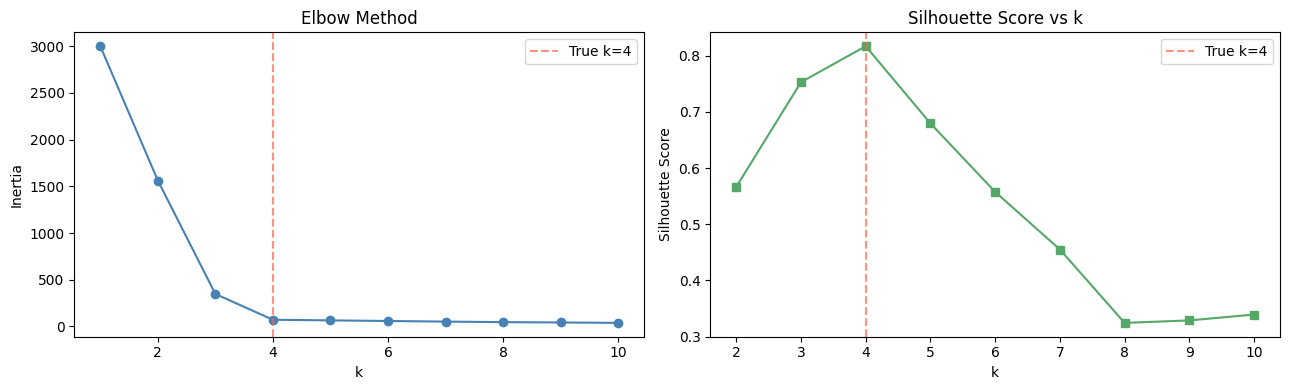

In [5]:
K_range  = range(1, 11)
inertias = []
sil_scores = []

scaler   = pipeline['scaler']
X_sc     = scaler.transform(X_raw)

for k in K_range:
    km_k = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    lbl  = km_k.fit_predict(X_sc)
    inertias.append(km_k.inertia_)
    sil_scores.append(silhouette_score(X_sc, lbl) if k > 1 else np.nan)
    print(f"  k={k} | Inertia: {inertias[-1]:.2f}" +
          (f" | Silhouette: {sil_scores[-1]:.4f}" if k > 1 else ""))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(list(K_range), inertias, marker='o', color='steelblue')
ax1.axvline(4, linestyle='--', color='tomato', alpha=0.7, label='True k=4')
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method'); ax1.legend()

ax2.plot(list(K_range)[1:], sil_scores[1:], marker='s', color='#55A868')
ax2.axvline(4, linestyle='--', color='tomato', alpha=0.7, label='True k=4')
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score vs k'); ax2.legend()

plt.tight_layout(); plt.show()

## 6. Silhouette Plot

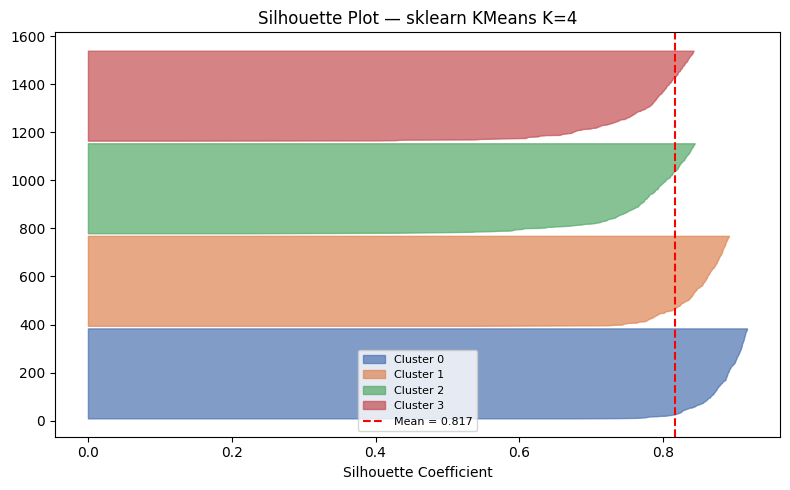

In [6]:
sil_vals = silhouette_samples(X_scaled, labels)
sil_avg  = silhouette_score(X_scaled, labels)

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10
for j in range(K):
    vals_j  = np.sort(sil_vals[labels == j])
    y_upper = y_lower + len(vals_j)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals_j,
                     alpha=0.7, color=colors[j], label=f'Cluster {j}')
    y_lower = y_upper + 10

ax.axvline(sil_avg, color='red', linestyle='--', label=f'Mean = {sil_avg:.3f}')
ax.set_xlabel('Silhouette Coefficient')
ax.set_title('Silhouette Plot — sklearn KMeans K=4')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 7. Inertia Convergence Curve

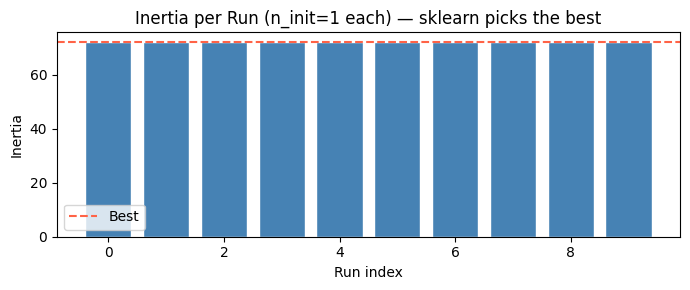

In [7]:
# sklearn doesn't expose per-iteration inertia directly,
# but we can re-run with verbose and capture, or plot from elbow sweep.
# Instead, show inertia per run (n_init=10) to visualise stability.

run_inertias = []
for seed in range(10):
    km_r = KMeans(n_clusters=K, init='k-means++', n_init=1, random_state=seed)
    km_r.fit(X_sc)
    run_inertias.append(km_r.inertia_)

plt.figure(figsize=(7, 3))
plt.bar(range(10), run_inertias, color='steelblue', edgecolor='white')
plt.axhline(min(run_inertias), color='tomato', linestyle='--', label='Best')
plt.xlabel('Run index'); plt.ylabel('Inertia')
plt.title('Inertia per Run (n_init=1 each) — sklearn picks the best')
plt.legend(); plt.tight_layout(); plt.show()

## 8. Save Pipeline to `../Models/`

In [8]:
save_path = '../Models/kmeans_sklearn.joblib'
joblib.dump(pipeline, save_path)

size_kb = os.path.getsize(save_path) / 1024
print(f"Saved → {save_path}  ({size_kb:.1f} KB)")

Saved → ../Models/kmeans_sklearn.joblib  (7.1 KB)


## 9. Reload & Verify

In [9]:
pipeline_loaded = joblib.load('../Models/kmeans_sklearn.joblib')
labels_r = pipeline_loaded.predict(X_raw)
print(f"Reloaded — unique labels: {np.unique(labels_r)}  |  Counts: {np.bincount(labels_r)}")

Reloaded — unique labels: [0 1 2 3]  |  Counts: [375 375 375 375]
